# <div style="color:blue;display:inline-block;border-radius:5px;background-color:#F0E68C;font-family:Nexa;overflow:hidden"><p style="padding:15px;color:blue;overflow:hidden;font-size:90%;letter-spacing:0.5px;margin:0"><b> </b> Import Modules</p></div>

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import os

from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

# <div style="color:blue;display:inline-block;border-radius:5px;background-color:#F0E68C;font-family:Nexa;overflow:hidden"><p style="padding:15px;color:blue;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b> </b> Load the Dataset</p></div>


In [2]:

# Paths
csv_files = [
    "csv/Alibaba.csv",
    "csv/Aliexpress.csv",
    "csv/Myntra.csv",
    "csv/Flipkart.csv",
    "csv/Meesho.csv",
    "csv/Lazada.csv",
    "csv/Amazon shopping.csv",
    "csv/Snapdeal.csv",
    "csv/Shein.csv",
    "csv/Daraz Online Shopping App.csv",
    "csv/Walmart.csv"
]
json_files = [
    "json/Alibaba.json",
    "json/Aliexpress.json",
    "json/Myntra.json",
    "json/Flipkart.json",
    "json/Meesho.json",
    "json/Lazada.json",
    "json/Amazon shopping.json",
    "json/Snapdeal.json",
    "json/Shein.json",
    "json/Daraz Online Shopping App.json",
    "json/Walmart.json"
]

# Load CSV
csv_data = {os.path.basename(f).split('.')[0]: pd.read_csv(f) for f in csv_files}

# Load JSON
json_data = {}
for f in json_files:
    with open(f, 'r') as file:
        json_data[os.path.basename(f).split('.')[0]] = pd.json_normalize(json.load(file))


In [3]:
csv_data["Alibaba"].head()

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,appName
0,275f465b-a58b-439e-ae7c-f9f6dcf2634d,Trying to use the on website is almost impossi...,1,39,1720995717000,"Hi, we are sorry to hear that. Do share additi...",1.721048e+12,Alibaba
1,e6c13852-277e-451a-b8d5-dd92aea75402,Had to uninstall due to the amount of notifica...,3,60,1720501958000,"Hi, we are sorry to hear that. Do share additi...",1.721051e+12,Alibaba
2,254b3705-c54b-4ce4-8982-5b468d38231d,I order and it takes too long the shpping days...,1,7,1721866371000,NaN,NaN,Alibaba
3,c83c1e64-6aa3-42e8-9a56-0385a297b87b,Buyer beware! They have tons of listings that ...,1,2301,1611569460000,NaN,NaN,Alibaba
4,7a65dce8-3f09-4e4e-a263-55efebc13c65,It's all around a great app except for the fac...,4,1859,1545438323000,Thanks for your feedback. Could you tell us mo...,1.515586e+12,Alibaba


In [4]:
# Load CSV files into DataFrame
csv_data = [pd.read_csv(file) for file in csv_files]

# Load JSON files into DataFrame
json_data = [pd.DataFrame(json.load(open(file))) for file in json_files]

# Combine CSV and JSON data
combined_df = pd.concat(csv_data + json_data, ignore_index=True)

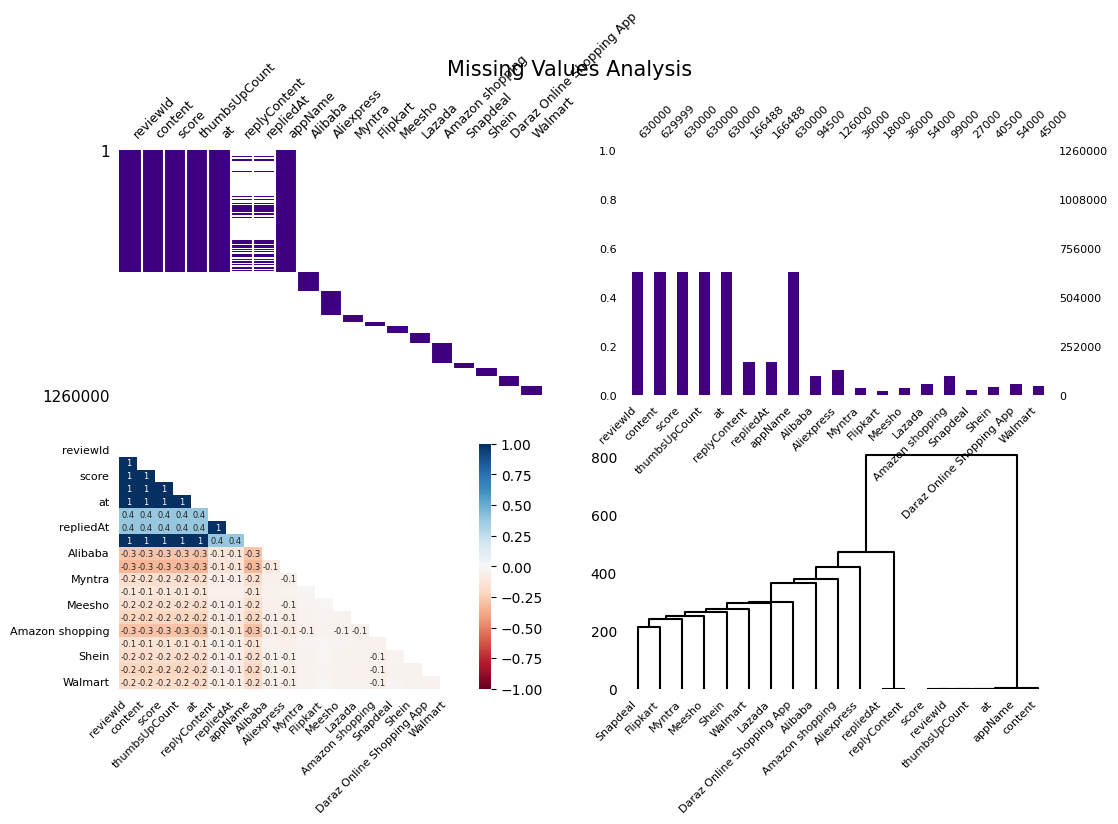

In [5]:
# !pip install missingno
import missingno as msno

fig, ax = plt.subplots(2,2,figsize=(12,7))
axs = np.ravel(ax)
msno.matrix(combined_df,  fontsize=9, color=(0.25,0,0.5),ax=axs[0]);
msno.bar(combined_df, fontsize=8, color=(0.25,0,0.5), ax=axs[1]);
msno.heatmap(combined_df,fontsize=8,ax=axs[2]);
msno.dendrogram(combined_df,fontsize=8,ax=axs[3], orientation='top')

fig.suptitle('Missing Values Analysis', y=1.01, fontsize=15)

# Save the plot
plt.savefig('missing_values_analysis.png')

# Show the plot
plt.show()

# <div style="color:blue;display:inline-block;border-radius:5px;background-color:#F0E68C;font-family:Nexa;overflow:hidden"><p style="padding:15px;color:blue;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b> </b> Data Cleaning</p></div>

In [6]:
print(combined_df.columns)

Index(['reviewId', 'content', 'score', 'thumbsUpCount', 'at', 'replyContent',
       'repliedAt', 'appName', 'Alibaba', 'Aliexpress', 'Myntra', 'Flipkart',
       'Meesho', 'Lazada', 'Amazon shopping', 'Snapdeal', 'Shein',
       'Daraz Online Shopping App', 'Walmart'],
      dtype='object')


In [7]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260000 entries, 0 to 1259999
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   reviewId                   630000 non-null  object 
 1   content                    629999 non-null  object 
 2   score                      630000 non-null  float64
 3   thumbsUpCount              630000 non-null  float64
 4   at                         630000 non-null  float64
 5   replyContent               166488 non-null  object 
 6   repliedAt                  166488 non-null  float64
 7   appName                    630000 non-null  object 
 8   Alibaba                    94500 non-null   object 
 9   Aliexpress                 126000 non-null  object 
 10  Myntra                     36000 non-null   object 
 11  Flipkart                   18000 non-null   object 
 12  Meesho                     36000 non-null   object 
 13  Lazada                     

In [8]:
# Check for missing values
print(combined_df.isnull().sum())

reviewId                      630000
content                       630001
score                         630000
thumbsUpCount                 630000
at                            630000
replyContent                 1093512
repliedAt                    1093512
appName                       630000
Alibaba                      1165500
Aliexpress                   1134000
Myntra                       1224000
Flipkart                     1242000
Meesho                       1224000
Lazada                       1206000
Amazon shopping              1161000
Snapdeal                     1233000
Shein                        1219500
Daraz Online Shopping App    1206000
Walmart                      1215000
dtype: int64


In [9]:
# Drop rows where reviews or ratings are missing
combined_df = combined_df.dropna(subset=['content', 'score'])

# Verify the result
print(combined_df.isnull().sum())


reviewId                          0
content                           0
score                             0
thumbsUpCount                     0
at                                0
replyContent                 463511
repliedAt                    463511
appName                           0
Alibaba                      629999
Aliexpress                   629999
Myntra                       629999
Flipkart                     629999
Meesho                       629999
Lazada                       629999
Amazon shopping              629999
Snapdeal                     629999
Shein                        629999
Daraz Online Shopping App    629999
Walmart                      629999
dtype: int64


In [10]:
# Ensure 'score' is treated as a categorical variable
combined_df['score'] = combined_df['score'].astype(int)

# Preview the data
combined_df[['appName', 'score']].head()


,appName,score
0,Alibaba,1
1,Alibaba,3
2,Alibaba,1
3,Alibaba,1
4,Alibaba,4


# <div style="color:blue;display:inline-block;border-radius:5px;background-color:#F0E68C;font-family:Nexa;overflow:hidden"><p style="padding:15px;color:blue;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b> </b> Exploratory Data Analysis (EDA)📊</p></div>

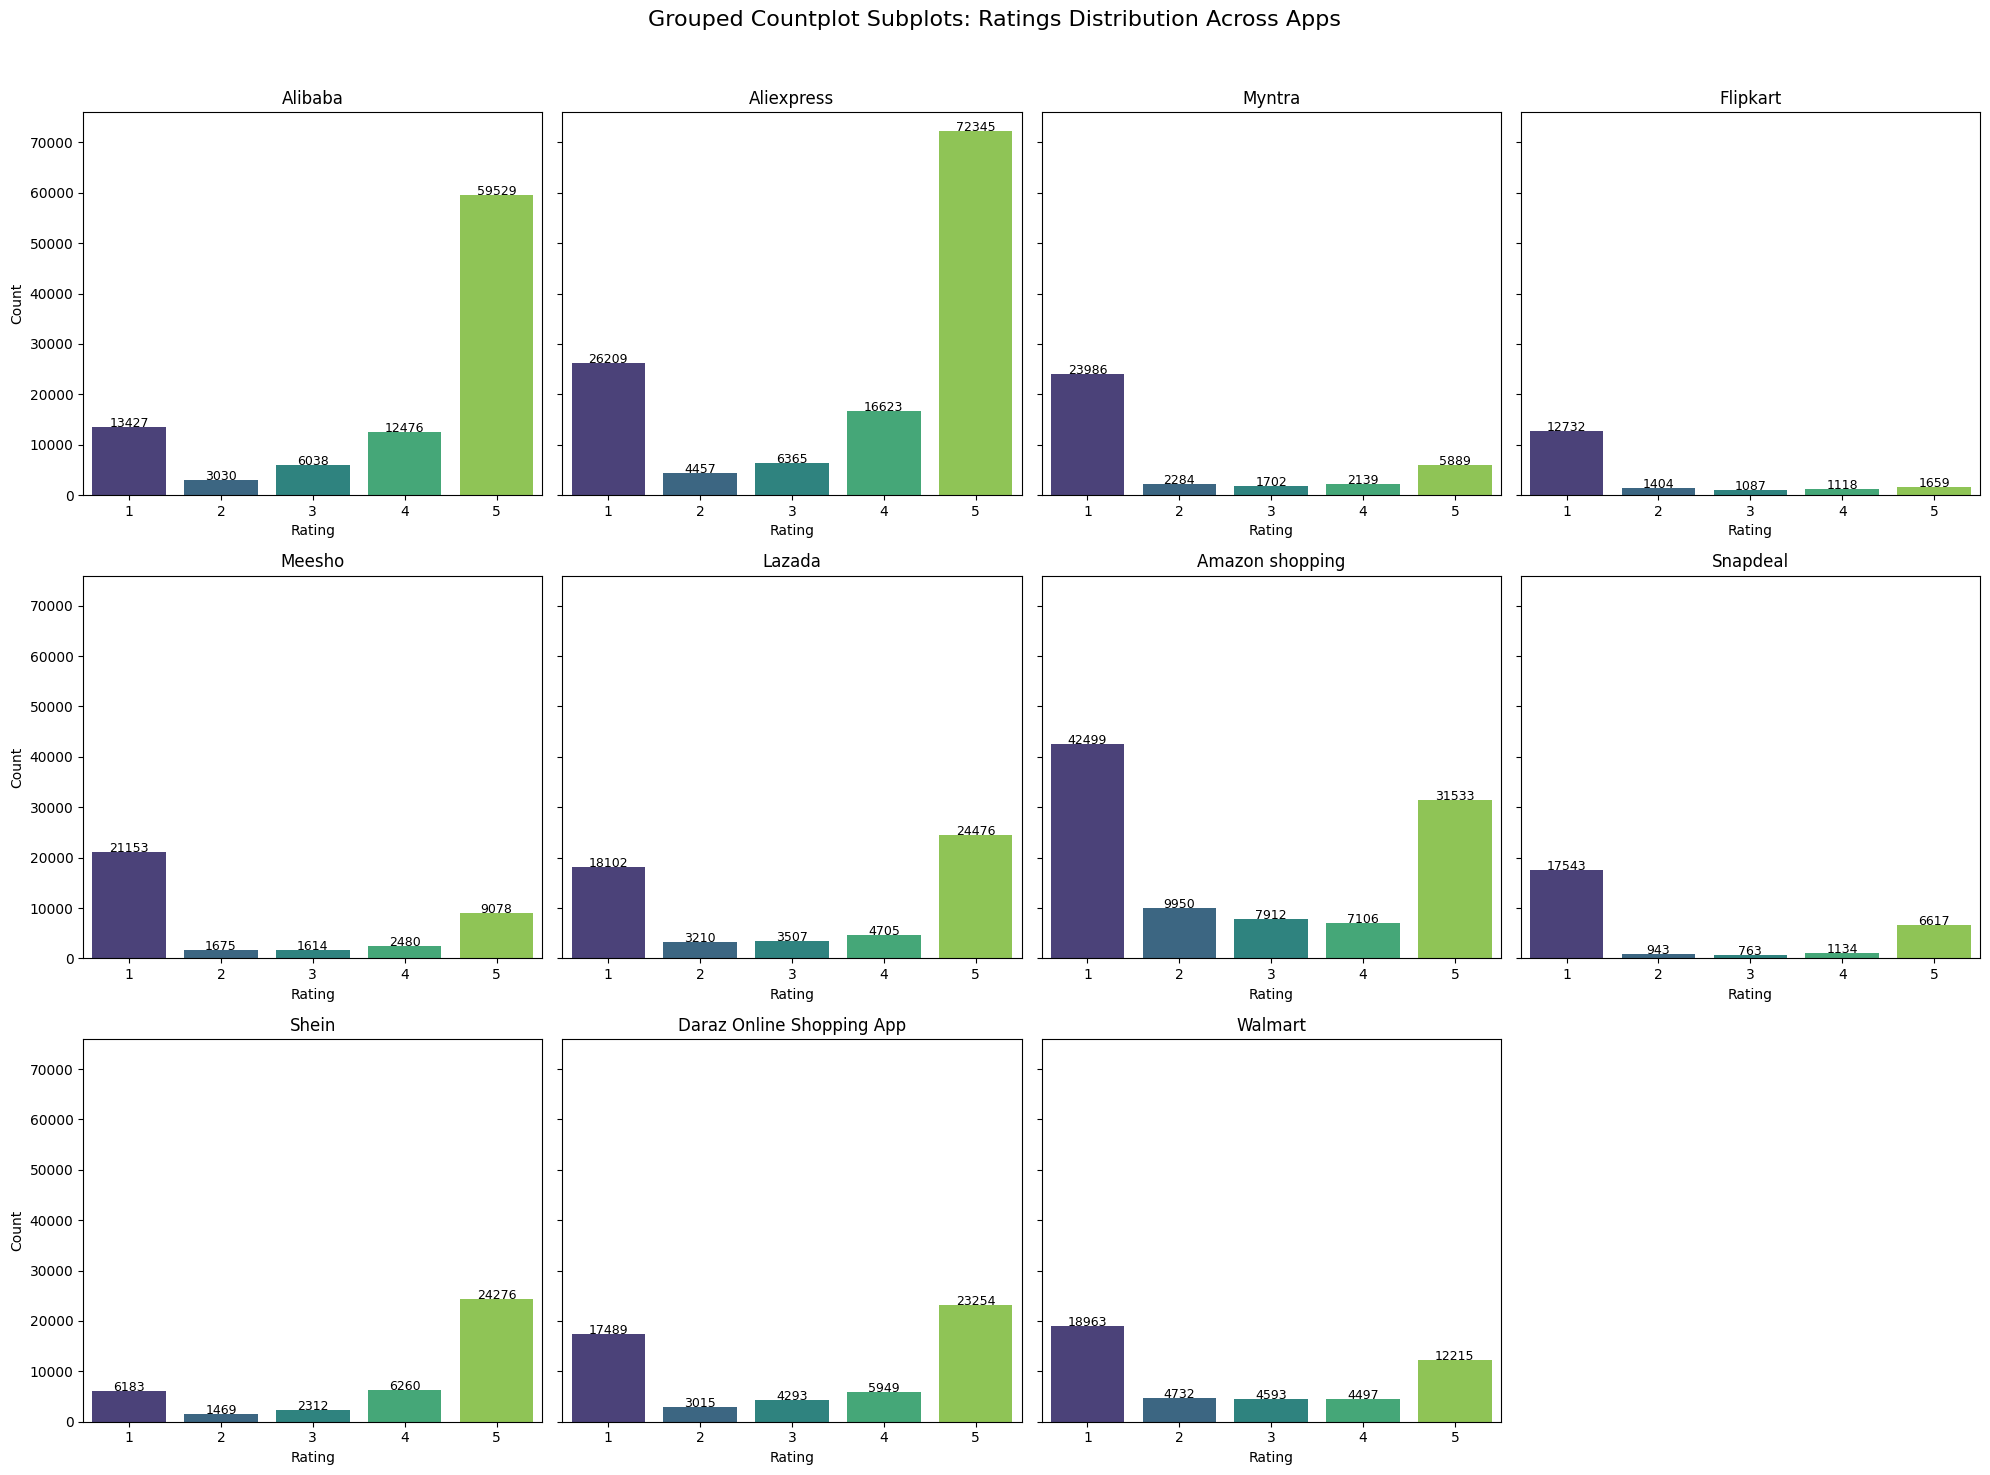

In [11]:
# Get a list of unique apps
apps = combined_df['appName'].unique()

# Define the subplot grid (e.g., 3 rows x 4 columns)
rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, figsize=(20, 15), sharey=True)
axes = axes.flatten()

# Plot countplots for each app
for i, app in enumerate(apps):
    ax = axes[i]
    app_data = combined_df[combined_df['appName'] == app]
    
    sns.countplot(
        data=app_data, 
        x='score', 
        ax=ax, 
        palette='viridis', 
        order=sorted(app_data['score'].unique())
    )
    ax.set_title(app, fontsize=12)
    ax.set_xlabel('Rating', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    
    # Annotate bar heights
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Only annotate bars with a height greater than 0
            ax.text(
                p.get_x() + p.get_width() / 2.,
                height + 1,
                f'{int(height)}',
                ha='center',
                fontsize=9
            )

# Remove unused subplots (if any apps < rows*cols)
for j in range(len(apps), len(axes)):
    fig.delaxes(axes[j])

# Add a global title
plt.suptitle('Grouped Countplot Subplots: Ratings Distribution Across Apps', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# <font size="+3" color='#059c99'><b> Analyze the Best-Performing Apps</b></font>

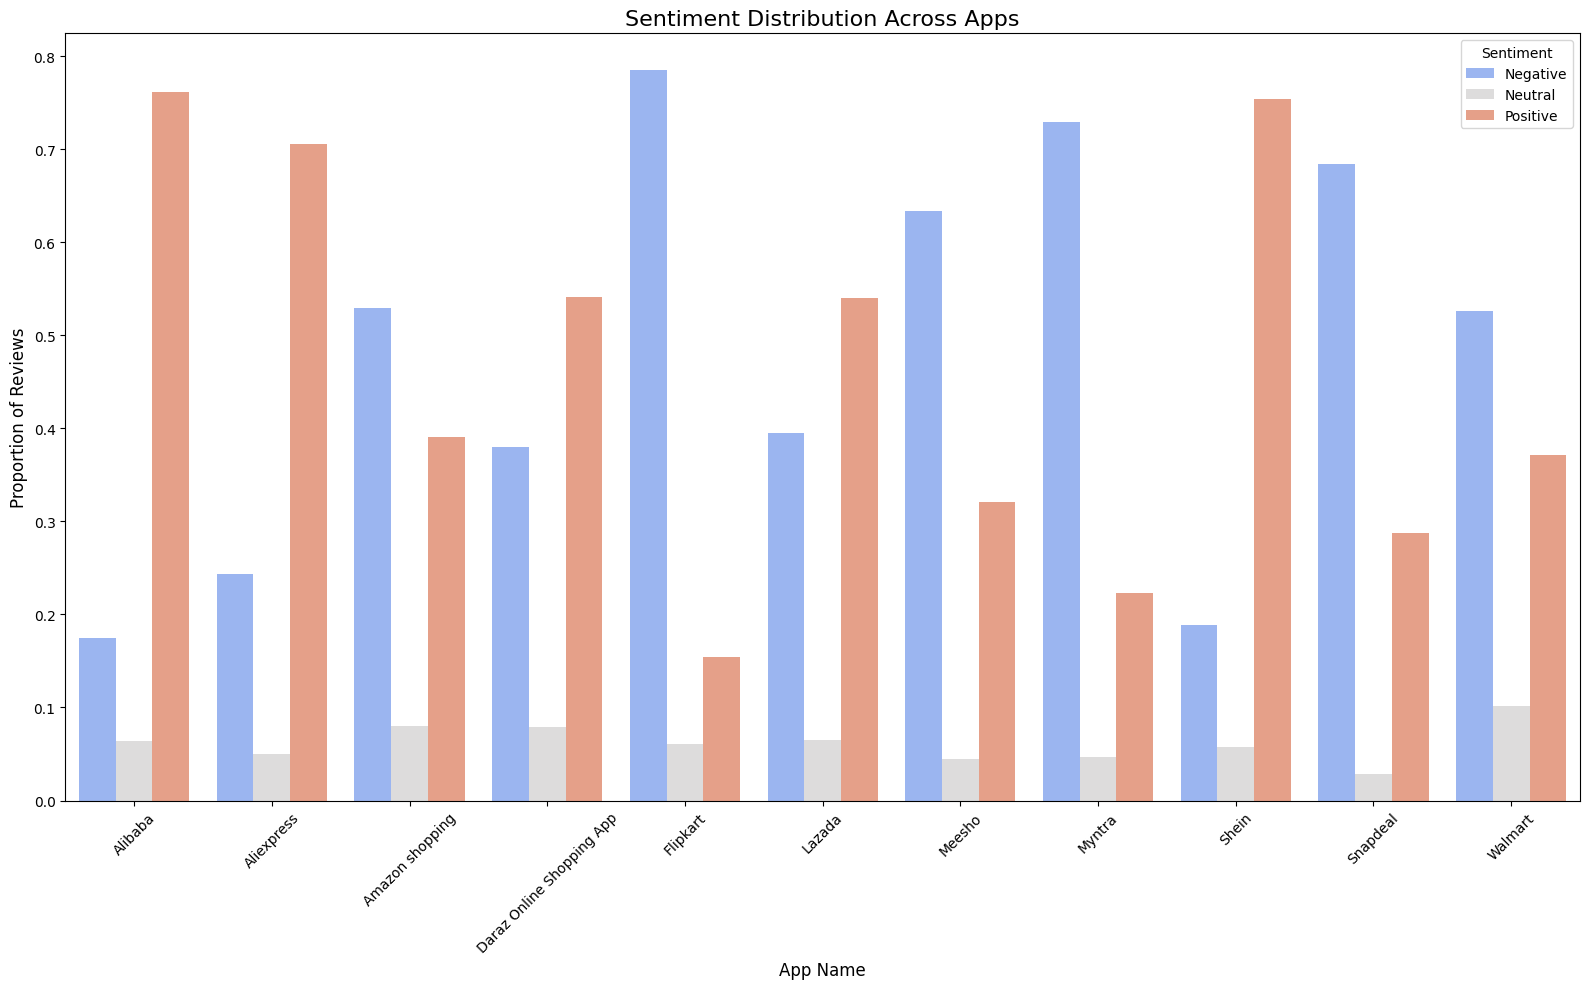

In [12]:
# Define sentiment labels
def categorize_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

# Apply sentiment categorization
combined_df['sentiment'] = combined_df['score'].apply(categorize_sentiment)

# Count sentiments per app
sentiment_counts = (
    combined_df.groupby(['appName', 'sentiment'])
    .size()
    .reset_index(name='count')  # Reset index to get 'count' as a column
)

# Calculate proportions per app
sentiment_counts['proportion'] = sentiment_counts.groupby('appName')['count'].transform(lambda x: x / x.sum())

# Plotting
plt.figure(figsize=(16, 10))
sns.barplot(data=sentiment_counts, x='appName', y='proportion', hue='sentiment', palette='coolwarm')
plt.title('Sentiment Distribution Across Apps', fontsize=16)
plt.xlabel('App Name', fontsize=12)
plt.ylabel('Proportion of Reviews', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()


In [13]:
# Calculate the percentage of positive reviews per app
app_performance = combined_df.groupby('appName')['sentiment'].apply(lambda x: (x == 'positive').mean() * 100).reset_index(name='positive_percentage')

# Identify top 3 apps with the highest percentage of positive reviews
top_apps = app_performance.sort_values('positive_percentage', ascending=False).head(3)['appName'].values
print("Top Performing Apps:", top_apps)

# Extract reviews for these top apps
top_apps_reviews = combined_df[combined_df['appName'].isin(top_apps)]

# Group by app name and sentiment to analyze trends
top_app_trends = top_apps_reviews.groupby(['appName', 'sentiment']).size().unstack(fill_value=0)
print(top_app_trends)


Top Performing Apps: ['Alibaba' 'Aliexpress' 'Amazon shopping']
sentiment        Negative  Neutral  Positive
appName                                     
Alibaba             16457     6038     72005
Aliexpress          30666     6365     88968
Amazon shopping     52449     7912     38639


# <div style="color:blue;display:inline-block;border-radius:5px;background-color:#F0E68C;font-family:Nexa;overflow:hidden"><p style="padding:15px;color:blue;overflow:hidden;font-size:100%;letter-spacing:0.5px;margin:0"><b> </b> Dynamic Sentiment Analysis </p></div>

- We will use a popular NLP package, VADER, to dynamically classify the sentiment of reviews based on their content. VADER work well with social media-type text, which includes informal language and slang.

# <font size="+2" color='#059c99'><b> Install the required libraries</b></font>

- We need `nltk` and `vaderSentiment`

In [14]:
pip install nltk vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]━━━━━━ 3/4 [nltk]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# <font size="+3" color='#059c99'><b> Sentiment Analysis with VADER</b></font>

- We'll create a function to classify the sentiment of each review using VADER and apply it to the `content` column.

In [15]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to classify sentiment based on VADER scores
def classify_sentiment(review):
    sentiment_score = analyzer.polarity_scores(review)
    compound_score = sentiment_score['compound']
    
    # Classify sentiment based on compound score
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment classification to the review content
combined_df['sentiment'] = combined_df['content'].apply(classify_sentiment)


# <font size="+2" color='#059c99'><b> Review the output </b></font>

In [16]:
combined_df[['content', 'sentiment']].head()

,content,sentiment
0,Trying to use the on website is almost impossi...,Negative
1,Had to uninstall due to the amount of notifica...,Negative
2,I order and it takes too long the shpping days...,Negative
3,Buyer beware! They have tons of listings that ...,Negative
4,It's all around a great app except for the fac...,Positive


# <font size="+2" color='#059c99'><b> Clustering Apps Based on Review Characteristics </b></font>

- Now, let's use K-Means clustering to group apps based on review length and sentiment. For sentiment, we'll convert the sentiment labels into numerical values (`Positive=1`,`Neutral =0`, `Negative = -1`).

In [17]:
sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
combined_df['sentiment_num'] = combined_df['sentiment'].map(sentiment_map)

# <font size="+2" color='#059c99'><b> Select features for clustering</b></font>

- We will use the review length and sentiment as features for clustering

In [18]:
# Create 'review_length' column based on the length of each review
combined_df['review_length'] = combined_df['content'].apply(len)

if 'sentiment_num' not in combined_df.columns:
    sentiment_mapping = {'positive': 1, 'negative': -1, 'neutral': 0}
    combined_df['sentiment_num'] = combined_df['sentiment'].map(sentiment_mapping)

# Now you can extract 'review_length' and 'sentiment_num' for analysis
X = combined_df[['review_length', 'sentiment_num']]

# Preview the result
print(X.head())


   review_length  sentiment_num
0            362             -1
1            369             -1
2            499             -1
3            494             -1
4            401              1


# <font size="+2" color='#059c99'><b> Normalize the features </b></font>

- Clustering often performs better when the data is normalized.

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# <font size="+2" color='#059c99'><b> K-Means clustering </b></font>

In [20]:
from sklearn.cluster import KMeans

# Choose the number of clusters (e.g., 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
combined_df['cluster'] = kmeans.fit_predict(X_scaled)


# <font size="+2" color='#059c99'><b> Review cluster results</b></font>

- Now, you can inspect how the apps are clustered based on review length and sentiment.

In [21]:
combined_df[['appName', 'review_length', 'sentiment', 'cluster']].head()


,appName,review_length,sentiment,cluster
0,Alibaba,362,Negative,2
1,Alibaba,369,Negative,2
2,Alibaba,499,Negative,2
3,Alibaba,494,Negative,2
4,Alibaba,401,Positive,2


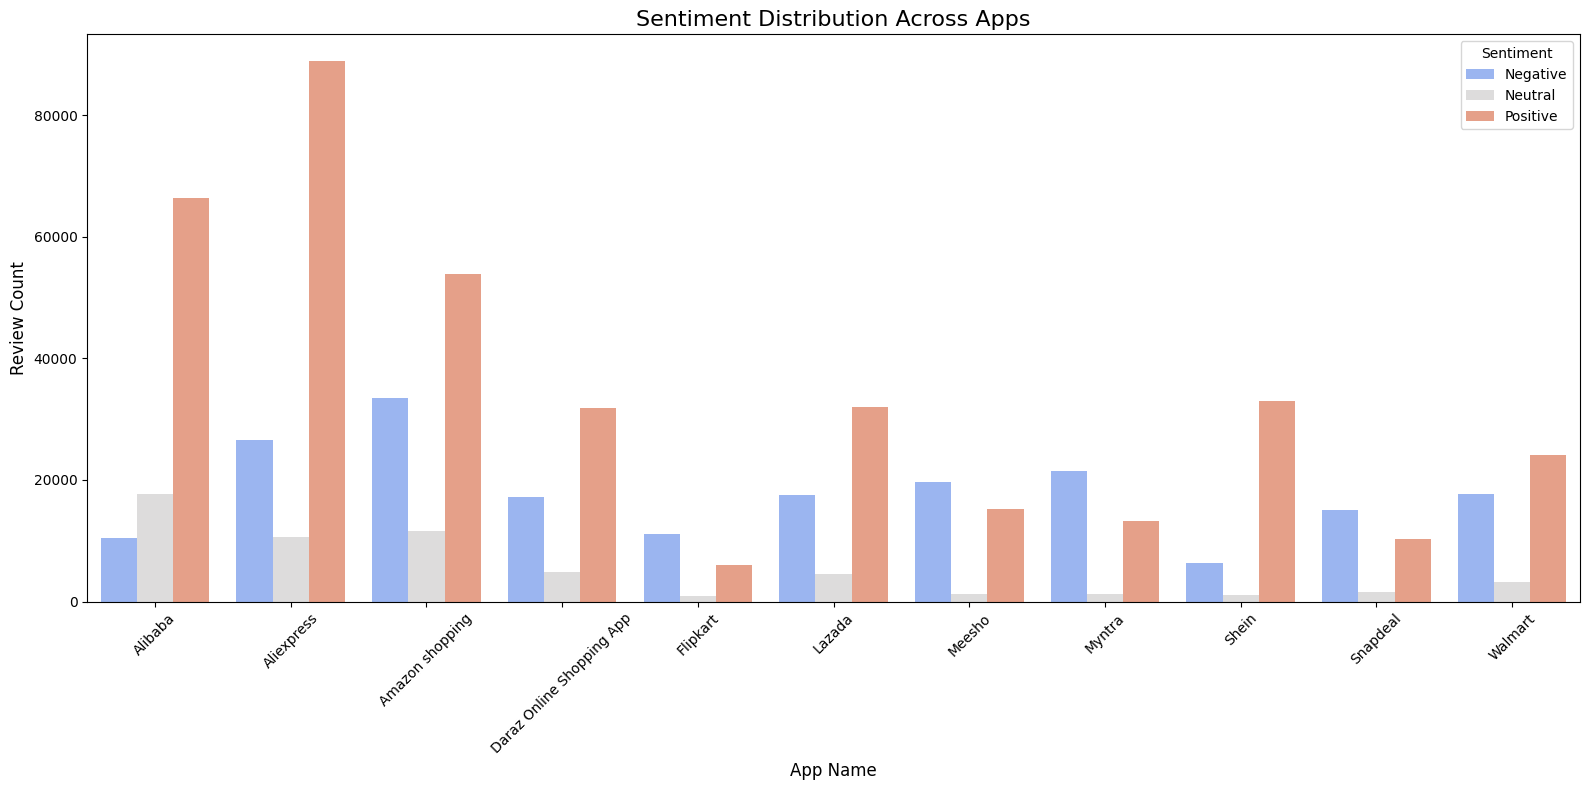

In [22]:
# Aggregate sentiment counts per app
sentiment_counts = combined_df.groupby(['appName', 'sentiment']).size().reset_index(name='count')

# Plotting
plt.figure(figsize=(16, 8))
sns.barplot(data=sentiment_counts, x='appName', y='count', hue='sentiment', palette='coolwarm')

# Customizing the plot
plt.title('Sentiment Distribution Across Apps', fontsize=16)
plt.xlabel('App Name', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.legend(title='Sentiment', loc='upper right')

# Display the plot
plt.tight_layout()
plt.show()


## Seaborn Visualizations (5 Graphs + Heatmap)

In [30]:
import seaborn as sns
sns.set_theme(style='whitegrid')

num_df = combined_df.select_dtypes(include=['number']).copy()
if num_df.empty:
    raise ValueError('No numeric columns available for seaborn visualizations.')

numeric_cols = num_df.columns.tolist()
x_col = numeric_cols[0]
y_col = numeric_cols[1] if len(numeric_cols) > 1 else numeric_cols[0]
hue_col = 'sentiment' if 'sentiment' in combined_df.columns else None


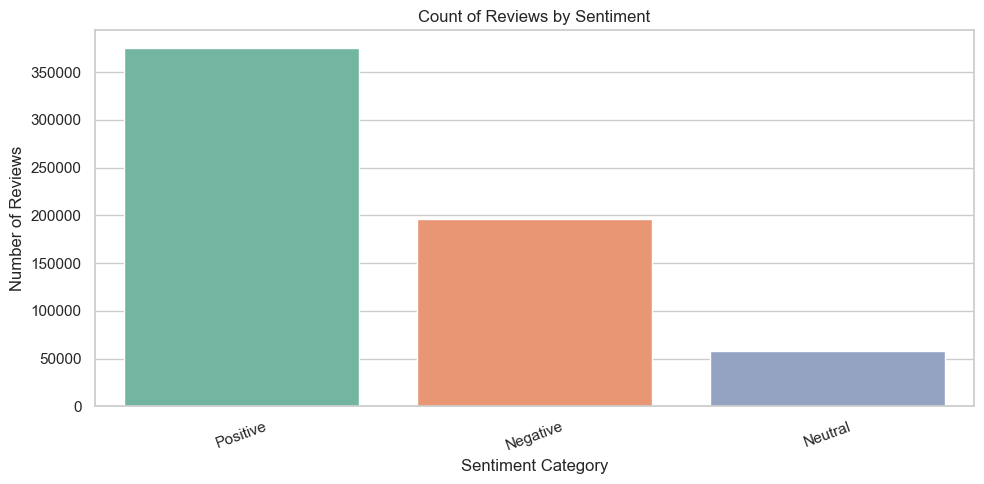

Interpretation: This countplot shows class balance across sentiment labels. A dominant bar indicates the dataset is skewed toward that sentiment category.


In [31]:
# 1) Count Plot
if 'sentiment' in combined_df.columns:
    plt.figure(figsize=(10, 5))
    order = combined_df['sentiment'].value_counts().index
    sns.countplot(data=combined_df, x='sentiment', order=order, palette='Set2')
    plt.title('Count of Reviews by Sentiment')
    plt.xlabel('Sentiment Category')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print('Interpretation: This countplot shows class balance across sentiment labels. A dominant bar indicates the dataset is skewed toward that sentiment category.')


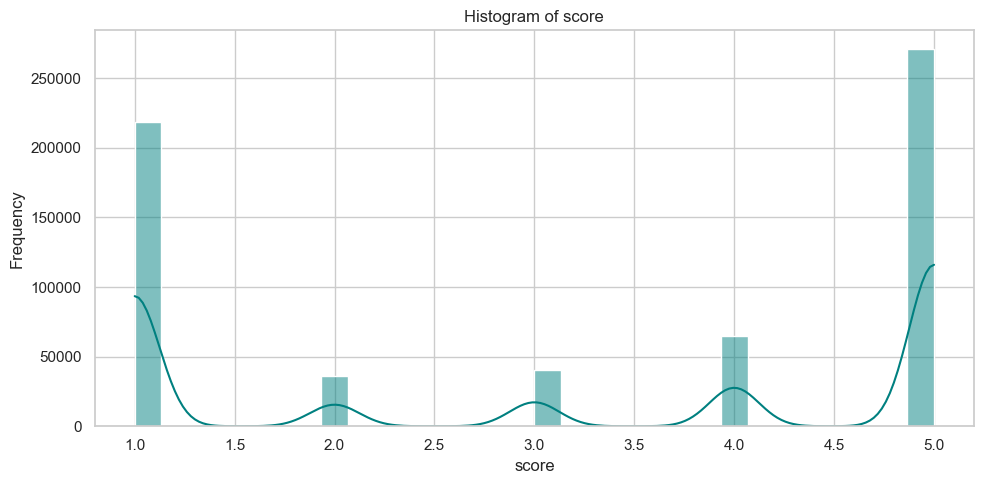

Interpretation: The histogram describes the distribution of score. KDE highlights whether values are concentrated, spread out, or skewed.


In [32]:
# 2) Histogram
plt.figure(figsize=(10, 5))
sns.histplot(data=combined_df, x=x_col, kde=True, bins=30, color='teal')
plt.title(f'Histogram of {x_col}')
plt.xlabel(x_col)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Interpretation: The histogram describes the distribution of {x_col}. KDE highlights whether values are concentrated, spread out, or skewed.')


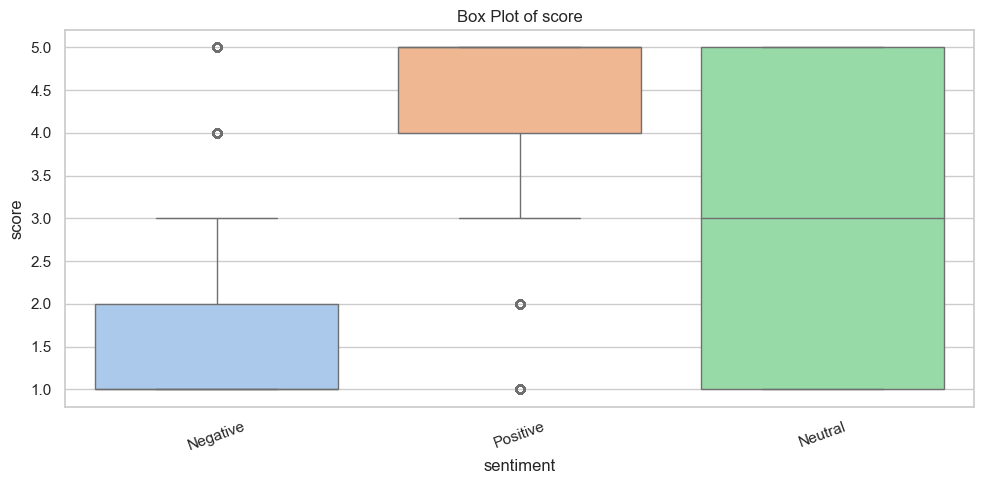

Interpretation: The boxplot summarizes median, IQR, and outliers of score. Differences between sentiment groups indicate variation in central tendency and spread.


In [33]:
# 3) Box Plot
plt.figure(figsize=(10, 5))
if hue_col:
    sns.boxplot(data=combined_df, x=hue_col, y=x_col, palette='pastel')
    plt.xlabel(hue_col)
    plt.ylabel(x_col)
    plt.xticks(rotation=20)
else:
    sns.boxplot(y=combined_df[x_col], color='lightblue')
    plt.ylabel(x_col)
plt.title(f'Box Plot of {x_col}')
plt.tight_layout()
plt.show()

print(f'Interpretation: The boxplot summarizes median, IQR, and outliers of {x_col}. Differences between sentiment groups indicate variation in central tendency and spread.')


In [ ]:
# 4) Scatter Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=combined_df, x=x_col, y=y_col, hue=hue_col, alpha=0.7, palette='deep')
plt.title(f'Scatter Plot: {x_col} vs {y_col}')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.tight_layout()
plt.show()

print(f'Interpretation: The scatter plot shows the relationship between {x_col} and {y_col}. Visible trend patterns suggest positive/negative association, while diffuse points suggest weak correlation.')


In [ ]:
# 5) Violin Plot
plt.figure(figsize=(10, 5))
if hue_col:
    sns.violinplot(data=combined_df, x=hue_col, y=x_col, palette='muted', inner='quartile')
    plt.xlabel(hue_col)
    plt.ylabel(x_col)
    plt.xticks(rotation=20)
else:
    sns.violinplot(y=combined_df[x_col], color='skyblue', inner='quartile')
    plt.ylabel(x_col)
plt.title(f'Violin Plot of {x_col}')
plt.tight_layout()
plt.show()

print(f'Interpretation: The violin plot combines density with quartiles for {x_col}. Wider sections indicate higher concentration of values and reveal multi-modal behavior if present.')


In [ ]:
# 6) Heatmap (Correlation)
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print('Interpretation: The heatmap quantifies pairwise linear relationships. Values near +1/-1 show strong positive/negative correlation, while values near 0 indicate weak linear association.')
